# Random Forest SHAP Explainability Fixed

Fresh copy created to avoid notebook editor cache after syntax-fix.


## 1. Imports

Install SHAP first if this cell raises an error:

```bash
pip install shap
```

or with the project virtual environment:

```bash
.venv/bin/pip install shap
```

In [1]:
import json
import pathlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import shap
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "SHAP is not installed. Install it with `pip install shap` or `.venv/bin/pip install shap`, then rerun this notebook."
    ) from exc

from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
shap.initjs()

## 2. Locate Repository and Load Artifacts

In [2]:
def find_repo_root():
    start_path = pathlib.Path(__file__).resolve().parent if "__file__" in globals() else pathlib.Path.cwd().resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "dataset" / "outputs" / "prediction.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing dataset/outputs/prediction.csv")


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "dataset" / "outputs" / "prediction.csv"
RESULTS_PATH = REPO_ROOT / "json-parameters" / "random-forest" / "random_forest_best_optimization_params.json"
MODEL_PATH = REPO_ROOT / "models_training" / "random-forest" / "rf_final_model.joblib"

with open(RESULTS_PATH, "r") as f:
    rf_results = json.load(f)

model_artifact = joblib.load(MODEL_PATH)
rf_model = model_artifact["model"]
onehot_encoder = model_artifact.get("onehot_encoder")
raw_feature_names = model_artifact["raw_feature_names"]
numeric_feature_names = model_artifact["numeric_feature_names"]
categorical_feature_names = model_artifact.get("categorical_feature_names", [])
encoded_feature_names = model_artifact["encoded_feature_names"]
label_encoder = model_artifact["label_encoder"]

print("Repo root:", REPO_ROOT)
print("Model path:", MODEL_PATH)
print("Results path:", RESULTS_PATH)
print("Raw features:", len(raw_feature_names))
print("Encoded features:", len(encoded_feature_names))
print("Classes:", list(label_encoder.classes_))
print("Best RF holdout macro F1:", rf_results.get("final_holdout_metrics", {}).get("macro_f1"))

Repo root: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project
Model path: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_training/random-forest/rf_final_model.joblib
Results path: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/random-forest/random_forest_best_optimization_params.json
Raw features: 25
Encoded features: 25
Classes: ['no_points', 'podium', 'points']
Best RF holdout macro F1: 0.708


## 3. Rebuild Holdout Feature Matrix

This rebuilds the same 2025 holdout feature matrix used by the trained RF model.

In [3]:
df = pd.read_csv(DATA_PATH).sort_values(["year", "round"]).reset_index(drop=True)

holdout_split = rf_results["holdout_split"]
holdout_years = holdout_split["holdout_test_years"]
exclude_years = holdout_split.get("excluded_years", [])
target_col = "target"

holdout_mask = df["year"].isin(holdout_years)
train_dev_mask = ~(holdout_mask | df["year"].isin(exclude_years))

df_train_dev = df.loc[train_dev_mask].reset_index(drop=True)
df_holdout = df.loc[holdout_mask].reset_index(drop=True)

raw_X_holdout = df_holdout[raw_feature_names].copy()

if categorical_feature_names:
    holdout_cat = onehot_encoder.transform(raw_X_holdout[categorical_feature_names].astype(str))
    encoded_categorical_names = onehot_encoder.get_feature_names_out(categorical_feature_names).tolist()
else:
    holdout_cat = np.empty((len(raw_X_holdout), 0))
    encoded_categorical_names = []

X_holdout = pd.concat(
    [
        raw_X_holdout[numeric_feature_names].reset_index(drop=True),
        pd.DataFrame(holdout_cat, columns=encoded_categorical_names),
    ],
    axis=1,
)
X_holdout = X_holdout[encoded_feature_names]

y_holdout = label_encoder.transform(df_holdout[target_col])
holdout_pred = rf_model.predict(X_holdout)
holdout_proba = rf_model.predict_proba(X_holdout)

print("Holdout years:", holdout_years)
print("Holdout rows:", len(df_holdout))
print("Holdout races:", df_holdout["raceId"].nunique())
print("Feature matrix shape:", X_holdout.shape)
print("Recomputed holdout macro F1:", round(f1_score(y_holdout, holdout_pred, average="macro"), 4))

print("Classification report:")
print(classification_report(y_holdout, holdout_pred, target_names=label_encoder.classes_, digits=4))

display(pd.DataFrame(
    confusion_matrix(y_holdout, holdout_pred),
    index=[f"true_{name}" for name in label_encoder.classes_],
    columns=[f"pred_{name}" for name in label_encoder.classes_],
))

Holdout years: [2025]
Holdout rows: 479
Holdout races: 24
Feature matrix shape: (479, 25)
Recomputed holdout macro F1: 0.708
Classification report:
              precision    recall  f1-score   support

   no_points     0.7982    0.7448    0.7706       239
      podium     0.6667    0.8889    0.7619        72
      points     0.6062    0.5774    0.5915       168

    accuracy                         0.7077       479
   macro avg     0.6904    0.7370    0.7080       479
weighted avg     0.7111    0.7077    0.7064       479



,pred_no_points,pred_podium,pred_points
true_no_points,178,5,56
true_podium,1,64,7
true_points,44,27,97


## 4. Compute SHAP Values

For Random Forest, `TreeExplainer` is the appropriate SHAP explainer.

For speed and plot readability, explanations are computed on a configurable sample of the holdout set. Set `EXPLAIN_SAMPLE_SIZE = None` to use all holdout rows.

In [4]:
EXPLAIN_SAMPLE_SIZE = None  # use an integer such as 200 for faster runs
RANDOM_STATE = 42

if EXPLAIN_SAMPLE_SIZE is None or EXPLAIN_SAMPLE_SIZE >= len(X_holdout):
    X_explain = X_holdout.copy()
    df_explain = df_holdout.copy()
else:
    X_explain = X_holdout.sample(EXPLAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)
    df_explain = df_holdout.loc[X_explain.index].copy()

explainer = shap.TreeExplainer(rf_model)
raw_shap_values = explainer.shap_values(X_explain)
expected_value = explainer.expected_value

print("Explained rows:", len(X_explain))
print("SHAP raw type:", type(raw_shap_values))
print("Expected value:", expected_value)

Explained rows: 479
SHAP raw type: <class 'numpy.ndarray'>
Expected value: [0.33236502 0.33386909 0.33376589]


## 5. Normalize SHAP Output for Multi-Class RF

Different SHAP versions return multi-class tree SHAP values differently:

```text
old format: list[class] of arrays with shape (n_samples, n_features)
new format: array with shape (n_samples, n_features, n_classes)
```

The helper below normalizes both formats into a dictionary keyed by class name.

In [5]:
def normalize_multiclass_shap_values(raw_values, class_names):
    if isinstance(raw_values, list):
        return {class_name: np.asarray(raw_values[idx]) for idx, class_name in enumerate(class_names)}

    values = np.asarray(raw_values)
    if values.ndim == 3:
        # SHAP commonly returns (n_samples, n_features, n_classes) for modern versions.
        if values.shape[2] == len(class_names):
            return {class_name: values[:, :, idx] for idx, class_name in enumerate(class_names)}
        # Fallback for uncommon (n_classes, n_samples, n_features).
        if values.shape[0] == len(class_names):
            return {class_name: values[idx, :, :] for idx, class_name in enumerate(class_names)}

    if values.ndim == 2 and len(class_names) == 2:
        return {class_names[1]: values}

    raise ValueError(f"Unsupported SHAP value shape: {values.shape}")


class_names = list(label_encoder.classes_)
shap_by_class = normalize_multiclass_shap_values(raw_shap_values, class_names)

for class_name, values in shap_by_class.items():
    print(class_name, values.shape)

no_points (479, 25)
podium (479, 25)
points (479, 25)


## 6. Global SHAP Importance

This aggregates absolute SHAP values across all classes. It answers:

> Which features influence the Random Forest predictions the most overall?

,feature,mean_abs_shap_no_points,mean_abs_shap_podium,mean_abs_shap_points,mean_abs_shap_all_classes
1,qualifying_position,0.09229,0.09846,0.06989,0.08688
0,grid,0.05181,0.06032,0.04712,0.05308
4,driver_std_position_prev,0.04971,0.03859,0.02130,0.03653
12,driver_points_avg_last3,0.03341,0.02500,0.01440,0.02427
6,constructor_std_position_prev,0.02641,0.02310,0.01251,0.02067
11,driver_podium_rate_last10,0.02260,0.02429,0.00795,0.01828
13,constructor_avg_position_last3,0.01567,0.01805,0.01408,0.01593
5,constructor_std_points_prev,0.01759,0.00905,0.01112,0.01259
18,points_gap_to_leader,0.00950,0.01139,0.00808,0.00966
3,driver_std_points_prev,0.01265,0.00740,0.00852,0.00953


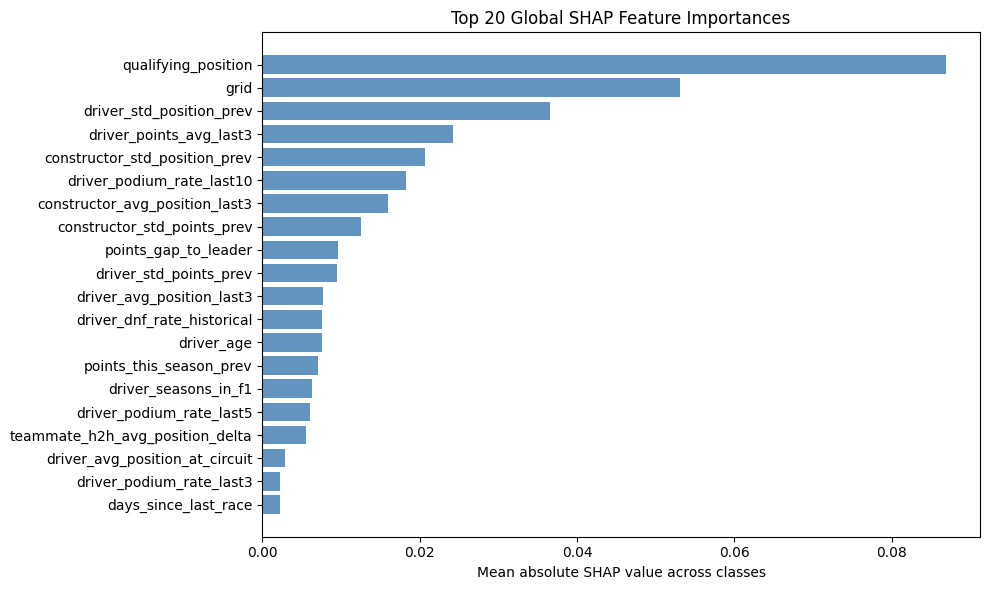

In [6]:
global_importance = pd.DataFrame({"feature": encoded_feature_names})

for class_name, values in shap_by_class.items():
    global_importance[f"mean_abs_shap_{class_name}"] = np.abs(values).mean(axis=0)

global_importance["mean_abs_shap_all_classes"] = global_importance[
    [col for col in global_importance.columns if col.startswith("mean_abs_shap_") and col != "mean_abs_shap_all_classes"]
].mean(axis=1)

global_importance = global_importance.sort_values("mean_abs_shap_all_classes", ascending=False)

display(global_importance.head(25).round(5))

TOP_N = min(20, len(global_importance))
plot_df = global_importance.head(TOP_N).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["feature"], plot_df["mean_abs_shap_all_classes"], color="steelblue", alpha=0.85)
ax.set_xlabel("Mean absolute SHAP value across classes")
ax.set_title(f"Top {TOP_N} Global SHAP Feature Importances")
plt.tight_layout()
plt.show()

## 7. Class-Specific SHAP Importance

These plots answer:

> Which features push the model toward each class?

For this task, inspect `points` carefully because it is the weakest class.

Top SHAP features for class: podium


,feature,mean_abs_shap
1,qualifying_position,0.09846
0,grid,0.06032
4,driver_std_position_prev,0.03859
12,driver_points_avg_last3,0.02500
11,driver_podium_rate_last10,0.02429
6,constructor_std_position_prev,0.02310
13,constructor_avg_position_last3,0.01805
18,points_gap_to_leader,0.01139
17,driver_dnf_rate_historical,0.01020
5,constructor_std_points_prev,0.00905


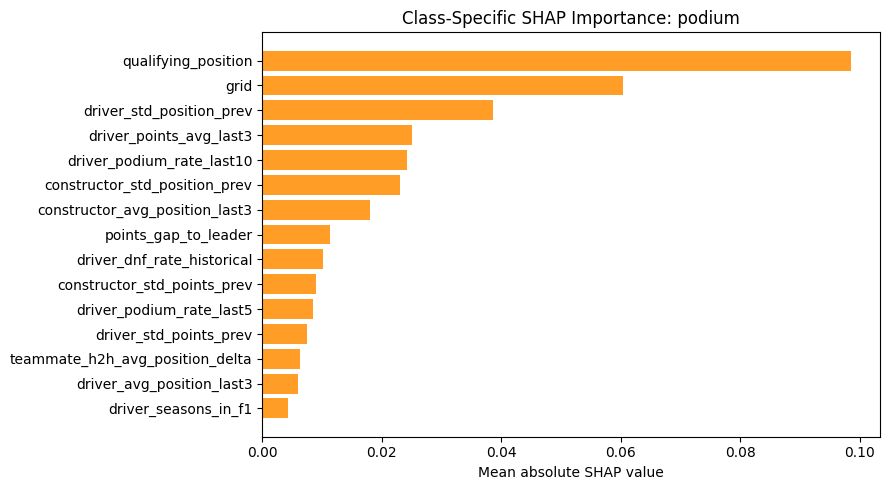

Top SHAP features for class: points


,feature,mean_abs_shap
1,qualifying_position,0.06989
0,grid,0.04712
4,driver_std_position_prev,0.02130
12,driver_points_avg_last3,0.01440
13,constructor_avg_position_last3,0.01408
6,constructor_std_position_prev,0.01251
5,constructor_std_points_prev,0.01112
2,driver_age,0.01061
17,driver_dnf_rate_historical,0.00884
8,driver_avg_position_last3,0.00858


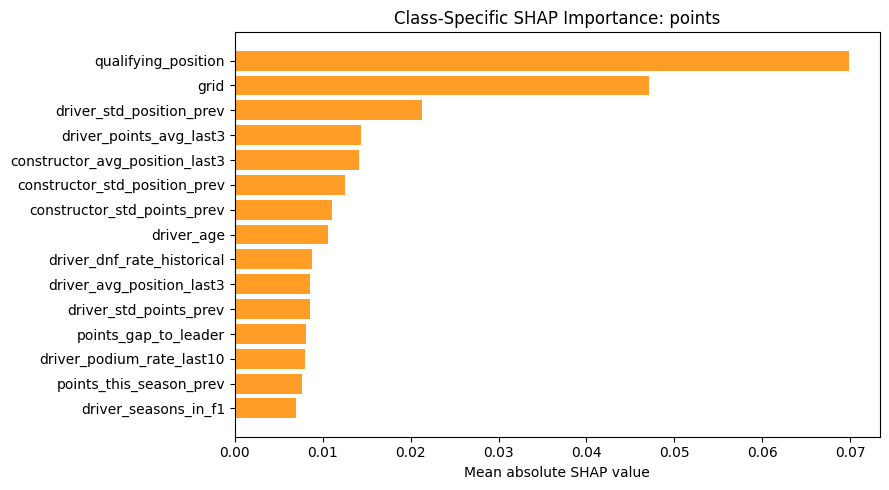

Top SHAP features for class: no_points


,feature,mean_abs_shap
1,qualifying_position,0.09229
0,grid,0.05181
4,driver_std_position_prev,0.04971
12,driver_points_avg_last3,0.03341
6,constructor_std_position_prev,0.02641
11,driver_podium_rate_last10,0.02260
5,constructor_std_points_prev,0.01759
13,constructor_avg_position_last3,0.01567
3,driver_std_points_prev,0.01265
7,points_this_season_prev,0.00969


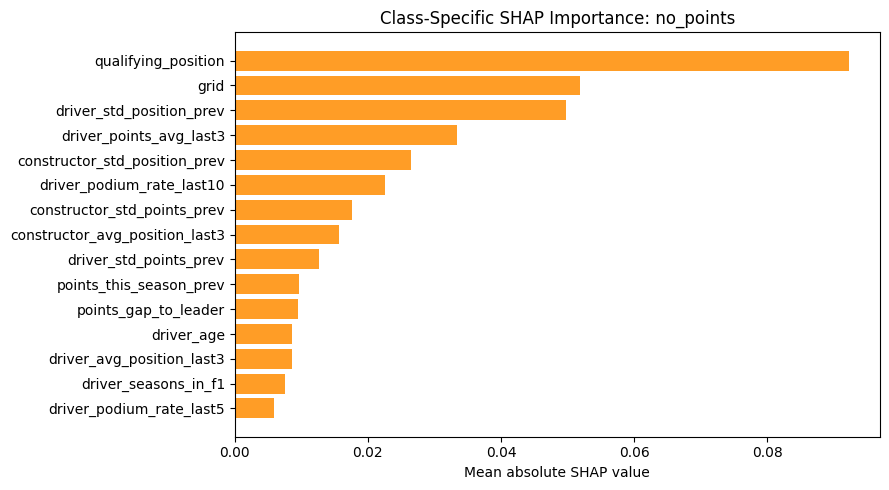

In [7]:
for class_name in ["podium", "points", "no_points"]:
    if class_name not in shap_by_class:
        continue

    class_importance = pd.DataFrame({
        "feature": encoded_feature_names,
        "mean_abs_shap": np.abs(shap_by_class[class_name]).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    print(f"Top SHAP features for class: {class_name}")
    display(class_importance.head(15).round(5))

    plot_df = class_importance.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="darkorange", alpha=0.85)
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_title(f"Class-Specific SHAP Importance: {class_name}")
    plt.tight_layout()
    plt.show()

## 8. SHAP Beeswarm / Summary Plots

The beeswarm plot shows both feature importance and direction:

- x-axis: SHAP value impact
- color: feature value
- each dot: one prediction row

For multi-class classification, we plot one beeswarm per class.

SHAP beeswarm for class: podium


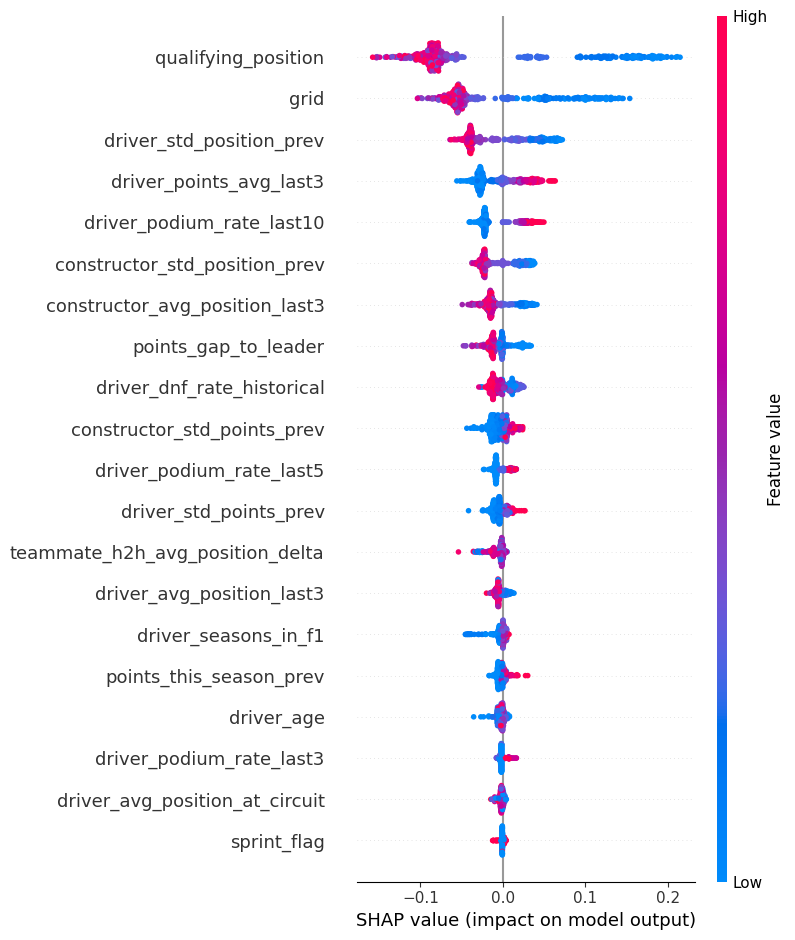

SHAP beeswarm for class: points


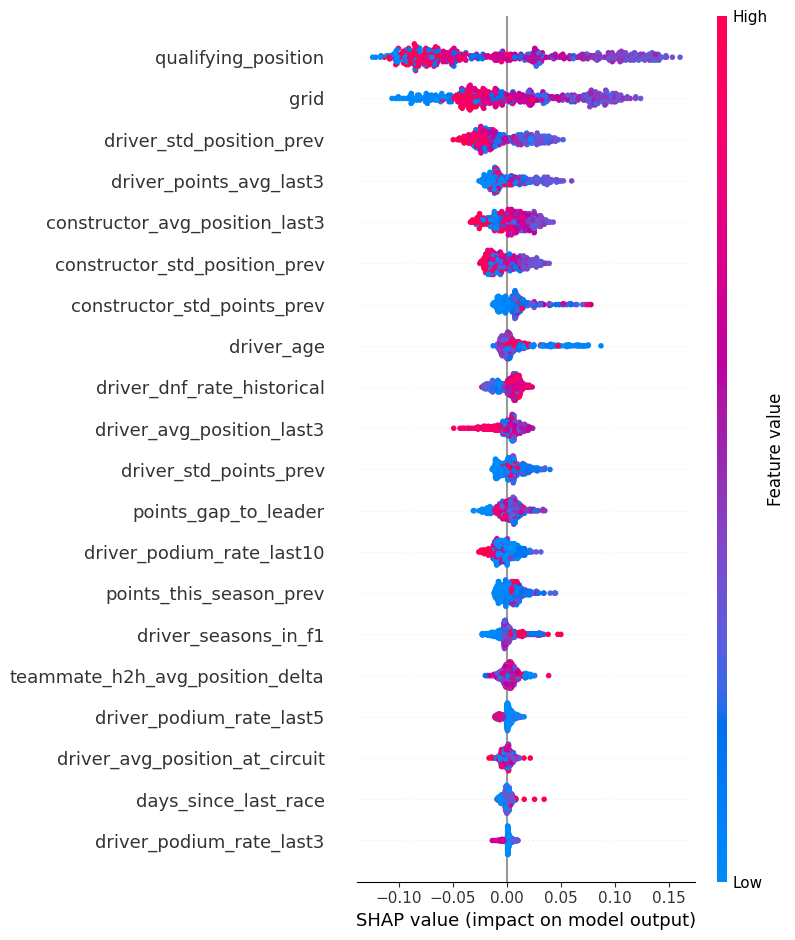

SHAP beeswarm for class: no_points


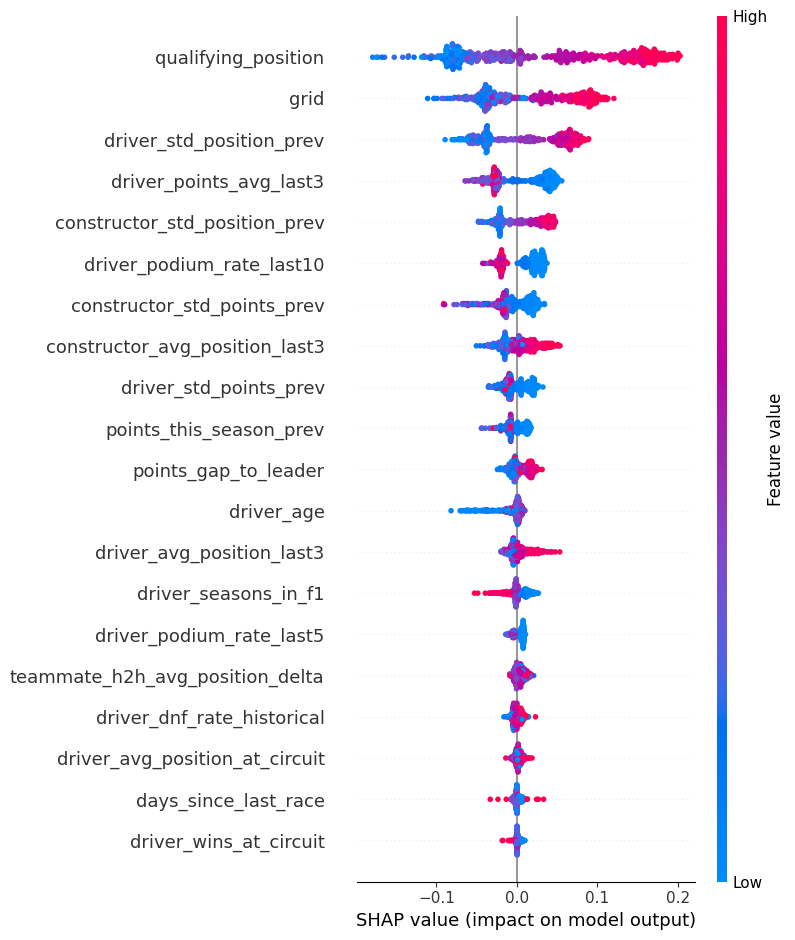

In [8]:
for class_name in ["podium", "points", "no_points"]:
    if class_name not in shap_by_class:
        continue
    print(f"SHAP beeswarm for class: {class_name}")
    shap.summary_plot(
        shap_by_class[class_name],
        X_explain,
        feature_names=encoded_feature_names,
        max_display=20,
        show=True,
    )

## 9. Per-Feature SHAP Dependence Plots

These plots visualize the SHAP value of each selected feature against its actual feature value.

This is useful for report explanations such as:

> Lower `qualifying_position` values push predictions toward `podium`.

The notebook plots the top features by global SHAP importance. Increase `TOP_FEATURES_FOR_DEPENDENCE` if you want more plots.

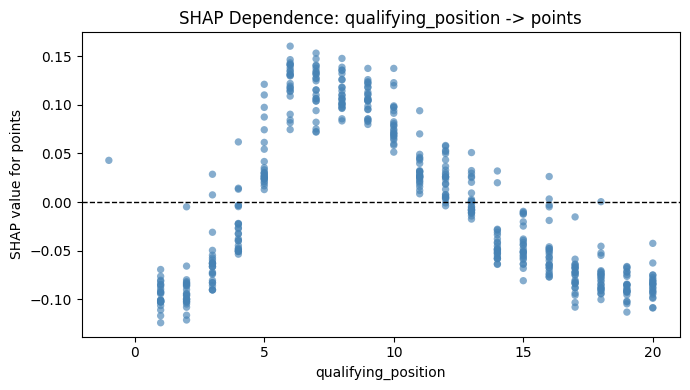

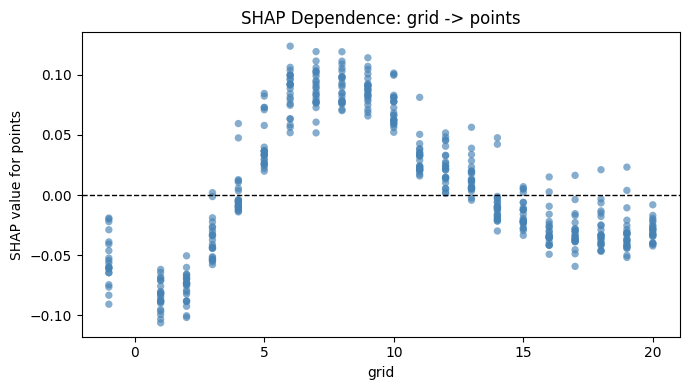

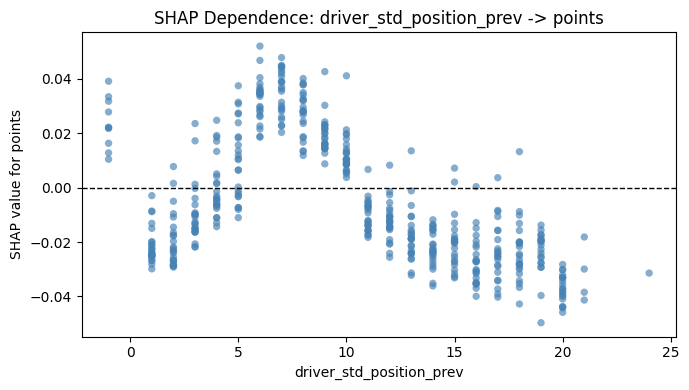

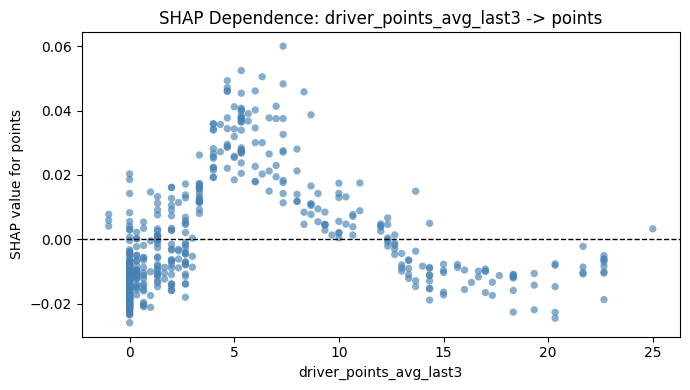

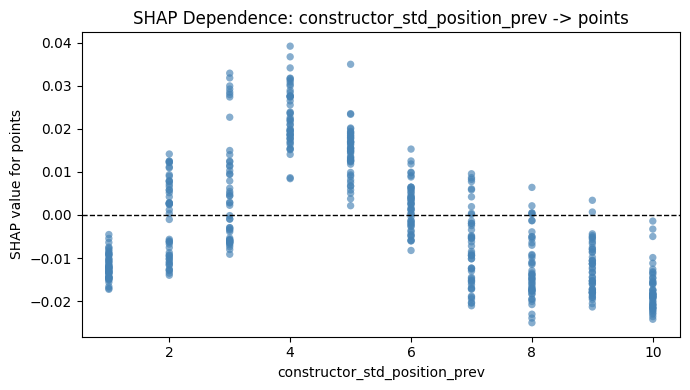

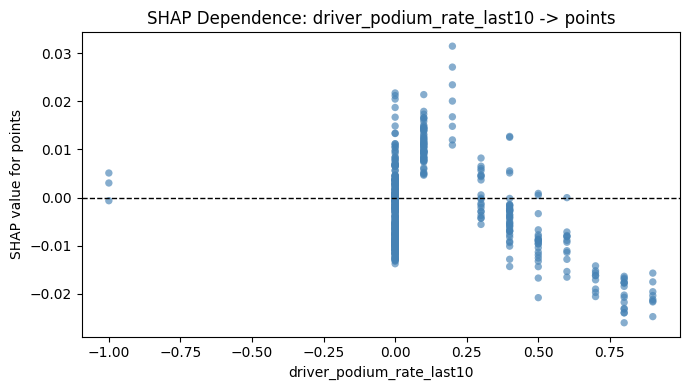

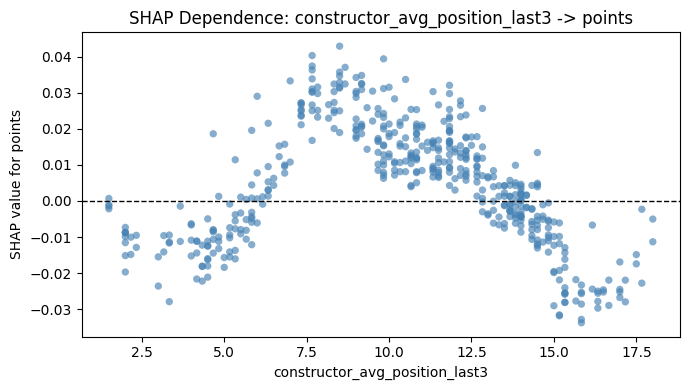

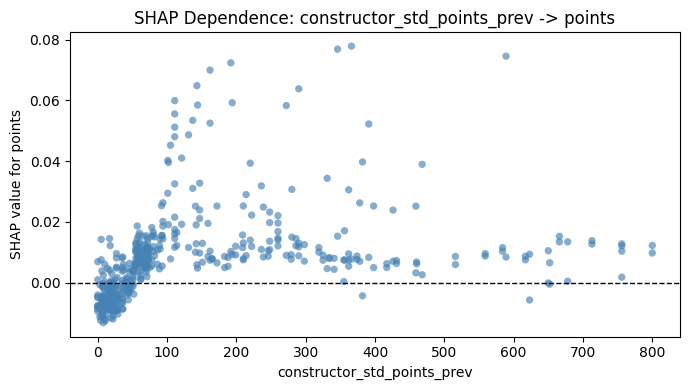

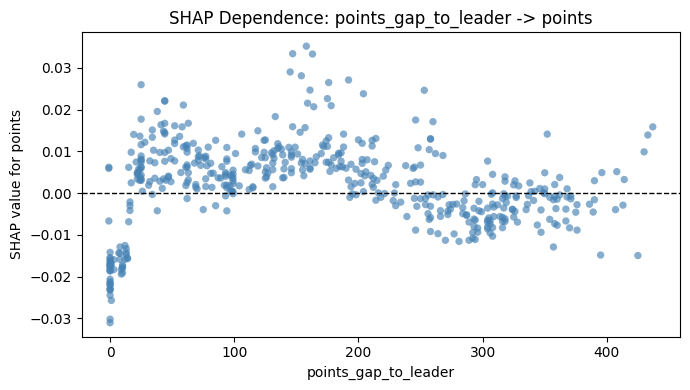

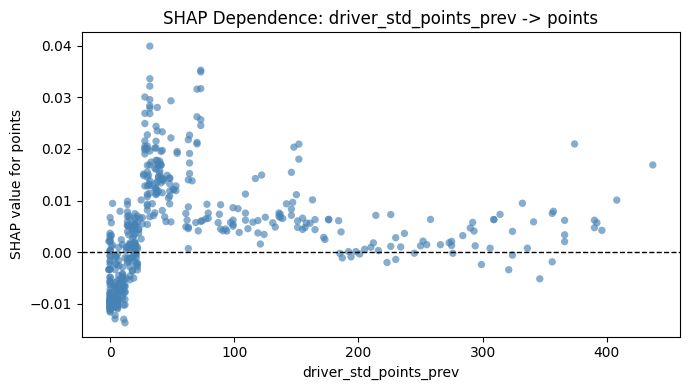

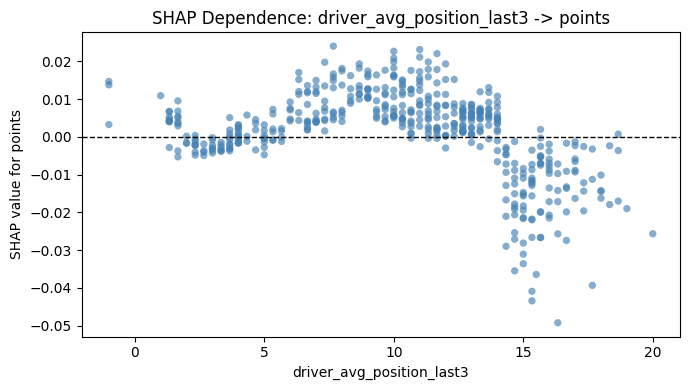

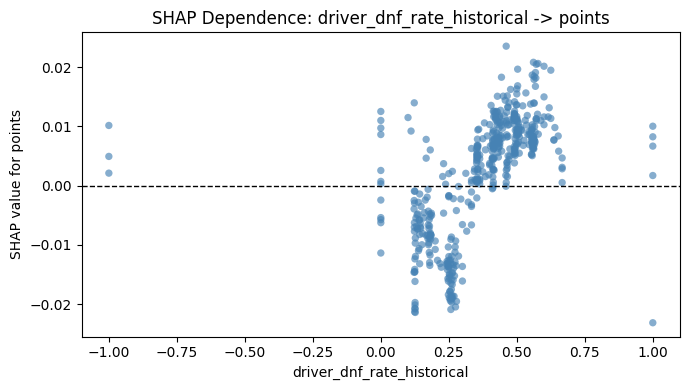

In [9]:
TOP_FEATURES_FOR_DEPENDENCE = 12
TARGET_CLASS_FOR_DEPENDENCE = "points"  # change to "podium" or "no_points" if needed

top_features = global_importance["feature"].head(TOP_FEATURES_FOR_DEPENDENCE).tolist()
class_values = shap_by_class[TARGET_CLASS_FOR_DEPENDENCE]

for feature in top_features:
    feature_idx = encoded_feature_names.index(feature)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(
        X_explain[feature],
        class_values[:, feature_idx],
        alpha=0.65,
        s=28,
        color="steelblue",
        edgecolors="none",
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"SHAP value for {TARGET_CLASS_FOR_DEPENDENCE}")
    ax.set_title(f"SHAP Dependence: {feature} -> {TARGET_CLASS_FOR_DEPENDENCE}")
    plt.tight_layout()
    plt.show()

## 10. Feature-Level SHAP Table

This table is useful for writing the report because it shows, for each feature and each class, its average absolute SHAP contribution.

In [10]:
feature_shap_table = global_importance.copy()
ordered_columns = [
    "feature",
    "mean_abs_shap_all_classes",
    *[f"mean_abs_shap_{class_name}" for class_name in class_names],
]
feature_shap_table = feature_shap_table[ordered_columns]

display(feature_shap_table.round(5))

OUTPUT_DIR = REPO_ROOT / "models_evaluation" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SHAP_TABLE_PATH = OUTPUT_DIR / "random_forest_shap_feature_importance.csv"
feature_shap_table.to_csv(SHAP_TABLE_PATH, index=False)
print("Saved SHAP feature importance table to:", SHAP_TABLE_PATH)

,feature,mean_abs_shap_all_classes,mean_abs_shap_no_points,mean_abs_shap_podium,mean_abs_shap_points
1,qualifying_position,0.08688,0.09229,0.09846,0.06989
0,grid,0.05308,0.05181,0.06032,0.04712
4,driver_std_position_prev,0.03653,0.04971,0.03859,0.02130
12,driver_points_avg_last3,0.02427,0.03341,0.02500,0.01440
6,constructor_std_position_prev,0.02067,0.02641,0.02310,0.01251
11,driver_podium_rate_last10,0.01828,0.02260,0.02429,0.00795
13,constructor_avg_position_last3,0.01593,0.01567,0.01805,0.01408
5,constructor_std_points_prev,0.01259,0.01759,0.00905,0.01112
18,points_gap_to_leader,0.00966,0.00950,0.01139,0.00808
3,driver_std_points_prev,0.00953,0.01265,0.00740,0.00852


Saved SHAP feature importance table to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_evaluation/outputs/random_forest_shap_feature_importance.csv


## 11. Local Explanation for One Prediction

This section explains a single driver-race prediction. Change `ROW_INDEX` to inspect another holdout row.

Race ID: 1145
Year / round: 2025 1
Driver ID: 1
True label: points
Predicted label: points
Predicted probabilities:


,class,probability
2,points,0.571067
1,podium,0.235798
0,no_points,0.193135


,feature,feature_value,shap_value_for_predicted_class,abs_shap
1,qualifying_position,8.00000,0.10064,0.10064
0,grid,8.00000,0.08484,0.08484
13,constructor_avg_position_last3,3.33333,-0.02792,0.02792
4,driver_std_position_prev,7.00000,0.02515,0.02515
18,points_gap_to_leader,214.00000,0.01311,0.01311
12,driver_points_avg_last3,10.00000,0.01303,0.01303
11,driver_podium_rate_last10,0.10000,0.00944,0.00944
17,driver_dnf_rate_historical,0.12360,-0.00772,0.00772
8,driver_avg_position_last3,6.00000,0.00712,0.00712
20,days_since_last_race,98.00000,-0.00697,0.00697


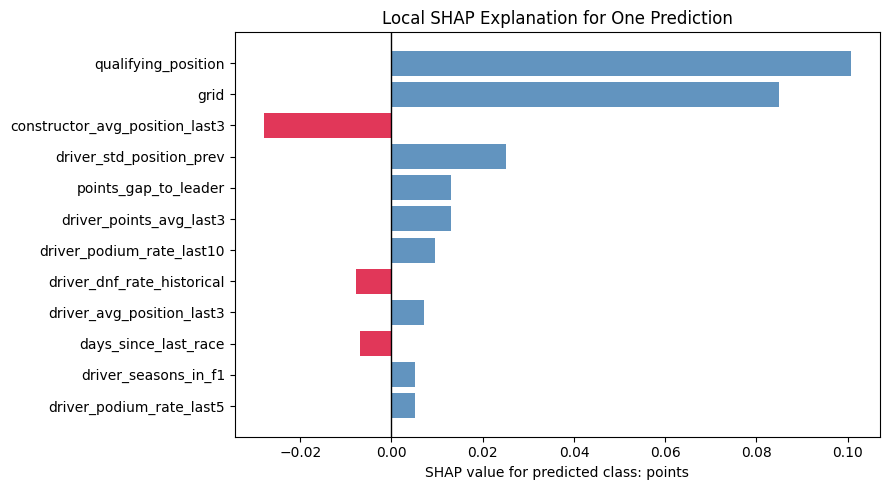

In [11]:
ROW_INDEX = 0

row = df_explain.iloc[ROW_INDEX]
x_row = X_explain.iloc[[ROW_INDEX]]
pred_encoded = rf_model.predict(x_row)[0]
pred_label = label_encoder.inverse_transform([pred_encoded])[0]
true_label = row[target_col]
proba = rf_model.predict_proba(x_row)[0]

print("Race ID:", row["raceId"])
print("Year / round:", row["year"], row["round"])
print("Driver ID:", row["driverId"])
print("True label:", true_label)
print("Predicted label:", pred_label)
print("Predicted probabilities:")
display(pd.DataFrame({"class": class_names, "probability": proba}).sort_values("probability", ascending=False))

local_class_values = shap_by_class[pred_label][ROW_INDEX]
local_explanation = pd.DataFrame({
    "feature": encoded_feature_names,
    "feature_value": x_row.iloc[0].to_numpy(),
    "shap_value_for_predicted_class": local_class_values,
    "abs_shap": np.abs(local_class_values),
}).sort_values("abs_shap", ascending=False)

display(local_explanation.head(15).round(5))

plot_df = local_explanation.head(12).iloc[::-1]
colors = np.where(plot_df["shap_value_for_predicted_class"] >= 0, "steelblue", "crimson")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["feature"], plot_df["shap_value_for_predicted_class"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(f"SHAP value for predicted class: {pred_label}")
ax.set_title("Local SHAP Explanation for One Prediction")
plt.tight_layout()
plt.show()

## 12. Report Notes

Suggested interpretation structure:

1. Report global top SHAP features.
2. Discuss class-specific differences, especially `points`.
3. Include one local explanation for a correct prediction and one for an error.
4. Mention that SHAP is computed on the 2025 holdout, so it explains final generalization behavior rather than training behavior.